In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, train_test_split

from sklearn.svm import SVR
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, AutoLocator)
from matplotlib import ticker
from matplotlib import cm


# Load data

In [3]:
dataCondMem = pd.read_excel('data/4.0-lbm-Conductivity.xlsx').dropna()

y = np.asarray(pd.DataFrame(dataCondMem, columns=['k']))
y = np.reshape(y, (len(y), ))
X = pd.DataFrame(dataCondMem, columns=['T', 'IEC'])

# Data processing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler.fit(X_train)

X_train = scaler.transform(X_train)


# Train the model

In [11]:
kernel = 'rbf'
C = 100
gamma = 5
epsilon = 0.1

model = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)

sigma_model =model.fit(X_train, y_train)

# Evaluate model performance

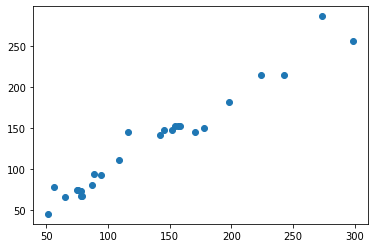

In [12]:
X_test_scaled = scaler.transform(X_test)

y_predicted = model.predict(X_test_scaled)

plt.scatter(y_test, y_predicted)

# Create a function to use the model to obtain predictions

In [13]:
def conductivityMem(T, IEC): 
    X = np.array([T, IEC])
    X = scaler.transform(X.reshape(1, -1))
    sigma_mem = model.predict(X)
    return sigma_mem